# Claim Detector - Threshold Tuning

Goal: pick the operating threshold that the Verifyn agent uses as a **pre-filter**. The classifier sits in front of the ReAct loop. If `score(CLAIM) < T` we short-circuit to `verdict=NO_CLAIMS` and skip the expensive LLM agent entirely.

## Cost model

| Outcome | Cost |
| --- | --- |
| Block a real CLAIM (false negative on CLAIM) | **HIGH** - we silently drop a fact-check that should have run |
| Pass a non-claim (false positive on CLAIM) | LOW - the agent wastes money and time, then returns NO_CLAIMS itself |
| Block a non-claim (true negative on CLAIM) | Saves money and time |
| Pass a real claim (true positive on CLAIM) | Required |

FP cost is asymmetrically much smaller than FN cost. So we want **CLAIM recall as high as possible**, accepting CLAIM precision around 0.75-0.80 (more non-claims slipping through is OK).

## Target

Pick `T` such that:
1. `CLAIM precision >= 0.75` (within the user-stated 0.75-0.80 band)
2. Subject to (1), `CLAIM recall` is maximised

Then write the resulting threshold into `verifyn/agent/constants.py` as `CLAIM_SCORE_THRESHOLD`.

## 0. Setup

In [1]:
# !pip install -q torch transformers datasets scikit-learn matplotlib pandas

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load model and test split

If you are running this in Colab, point `MODEL_DIR` to the unzipped checkpoint (or upload `claim_detector.zip` first). Locally, the default path resolves to `verifyn/claim_detector/model/`.

In [3]:
MODEL_DIR = Path("claim_detector_model")

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
model.to(DEVICE)
model.eval()
print(f"Loaded model from {MODEL_DIR}")
print(f"id2label: {model.config.id2label}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded model from claim_detector_model
id2label: {0: 'NOT_CLAIM', 1: 'CLAIM'}


In [4]:
# Same dataset used during training
from datasets import load_dataset

ds = load_dataset("Nithiwat/claim-detection")
print({split: len(ds[split]) for split in ds})
test_df = ds["test"].to_pandas().rename(columns={"checkworthiness": "label"})
test_df = test_df[test_df["text"].str.len() >= 10].reset_index(drop=True)
print(f"Test set: {len(test_df)} rows, label balance:")
print(test_df["label"].value_counts())

{'train': 23276, 'test': 7274, 'valid': 5819}
Test set: 7274 rows, label balance:
label
1    3691
0    3583
Name: count, dtype: int64


## 2. Inference on the full test set

In [5]:
import os

from tqdm.auto import tqdm

MAX_LENGTH = 256
BATCH_SIZE = 32 if DEVICE.type == "cpu" else 128

if DEVICE.type == "cpu":
    torch.set_num_threads(os.cpu_count() or 1)
    print(f"torch threads: {torch.get_num_threads()}")

model.to(DEVICE)
model.eval()

print(f"Scoring full test set: {len(test_df)} rows (device={DEVICE})")


def collate(batch):
    return tokenizer(
        batch,
        truncation=True,
        padding="longest",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )


loader = DataLoader(
    test_df["text"].tolist(),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate,
)

scores: list[float] = []
with torch.no_grad():
    for batch in tqdm(loader, desc="scoring", unit="batch"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs = torch.softmax(logits, dim=-1)[:, 1]
        scores.extend(probs.cpu().tolist())

test_df["score"] = scores

print(f"\nScored {len(test_df)} examples. Score distribution:")
print(test_df["score"].describe())
print(f"\nLabel balance:")
print(test_df["label"].value_counts())

Scoring full test set: 7274 rows (device=cuda)


scoring:   0%|          | 0/57 [00:00<?, ?batch/s]


Scored 7274 examples. Score distribution:
count    7274.000000
mean        0.488623
std         0.494257
min         0.000144
25%         0.000304
50%         0.090602
75%         0.999984
max         0.999988
Name: score, dtype: float64

Label balance:
label
1    3691
0    3583
Name: count, dtype: int64


## 3. Sanity check at default threshold = 0.5

In [6]:
y_true = test_df["label"].values
y_pred_default = (test_df["score"] >= 0.5).astype(int)

print("Default threshold T=0.5:")
print(f"  accuracy : {accuracy_score(y_true, y_pred_default):.4f}")
print(f"  precision: {precision_score(y_true, y_pred_default, pos_label=1):.4f}")
print(f"  recall   : {recall_score(y_true, y_pred_default, pos_label=1):.4f}")
print(f"  f1       : {f1_score(y_true, y_pred_default, pos_label=1):.4f}")
print()
print(classification_report(y_true, y_pred_default, target_names=["NOT_CLAIM", "CLAIM"]))

Default threshold T=0.5:
  accuracy : 0.9210
  precision: 0.9391
  recall   : 0.9027
  f1       : 0.9206

              precision    recall  f1-score   support

   NOT_CLAIM       0.90      0.94      0.92      3583
       CLAIM       0.94      0.90      0.92      3691

    accuracy                           0.92      7274
   macro avg       0.92      0.92      0.92      7274
weighted avg       0.92      0.92      0.92      7274



## 4. Precision-Recall sweep

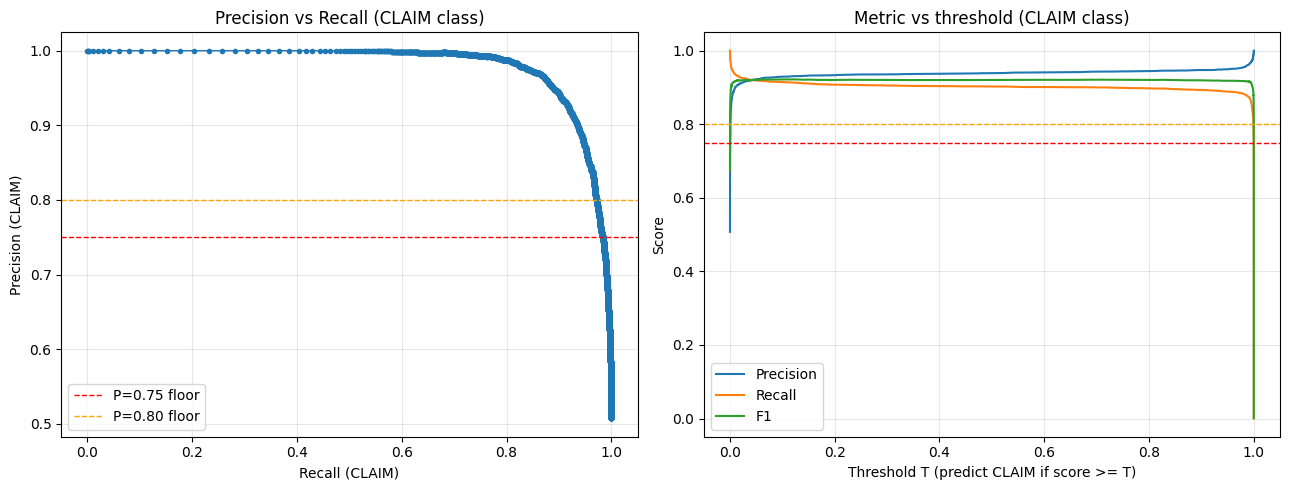

In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_true, test_df["score"].values, pos_label=1)
f1s = np.where((precisions + recalls) > 0, 2 * precisions * recalls / (precisions + recalls + 1e-12), 0.0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(recalls, precisions, marker=".", linewidth=1)
ax[0].set_xlabel("Recall (CLAIM)")
ax[0].set_ylabel("Precision (CLAIM)")
ax[0].set_title("Precision vs Recall (CLAIM class)")
ax[0].grid(alpha=0.3)
ax[0].axhline(0.75, color="red", linestyle="--", linewidth=1, label="P=0.75 floor")
ax[0].axhline(0.80, color="orange", linestyle="--", linewidth=1, label="P=0.80 floor")
ax[0].legend()

ax[1].plot(thresholds, precisions[:-1], label="Precision")
ax[1].plot(thresholds, recalls[:-1], label="Recall")
ax[1].plot(thresholds, f1s[:-1], label="F1")
ax[1].set_xlabel("Threshold T (predict CLAIM if score >= T)")
ax[1].set_ylabel("Score")
ax[1].set_title("Metric vs threshold (CLAIM class)")
ax[1].grid(alpha=0.3)
ax[1].axhline(0.75, color="red", linestyle="--", linewidth=1)
ax[1].axhline(0.80, color="orange", linestyle="--", linewidth=1)
ax[1].legend()

plt.tight_layout()
plt.savefig("threshold_tuning_curves.png", dpi=150)
plt.show()

## 5. Pick the operating threshold

In [8]:
def best_threshold(target_precision: float):
    valid = []
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p >= target_precision:
            valid.append((t, p, r))
    if not valid:
        return None
    # Maximise recall first, break ties on lower threshold (more aggressive blocking)
    valid.sort(key=lambda x: (-x[2], x[0]))
    return valid[0]


candidates = []
for target_p in [0.75, 0.78, 0.80]:
    pick = best_threshold(target_p)
    if pick is None:
        print(f"target_p={target_p} -> no threshold reaches this precision")
        continue
    t, p, r = pick
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    candidates.append({"target_p": target_p, "T": t, "precision": p, "recall": r, "f1": f1})

cands_df = pd.DataFrame(candidates)
print(cands_df.to_string(index=False))

 target_p        T  precision   recall       f1
     0.75 0.000549   0.750052 0.983744 0.851149
     0.78 0.000785   0.780039 0.976158 0.867148
     0.80 0.001007   0.800134 0.971823 0.877661


## 6. Confusion matrix at the chosen threshold

In [9]:
CHOSEN_T = float(cands_df.iloc[0]["T"])
print(f"Chosen threshold: T = {CHOSEN_T:.4f}")

y_pred_chosen = (test_df["score"] >= CHOSEN_T).astype(int)
cm = confusion_matrix(y_true, y_pred_chosen)
labels = ["NOT_CLAIM", "CLAIM"]

print("\nConfusion matrix at chosen T:")
print(f"{'':>12} {'Pred NOT':>10} {'Pred CLAIM':>12}")
for i, name in enumerate(labels):
    print(f"{name:>12} {cm[i][0]:>10} {cm[i][1]:>12}")

print("\nClassification report at chosen T:")
print(classification_report(y_true, y_pred_chosen, target_names=labels, digits=4))

Chosen threshold: T = 0.0005

Confusion matrix at chosen T:
               Pred NOT   Pred CLAIM
   NOT_CLAIM       2373         1210
       CLAIM         60         3631

Classification report at chosen T:
              precision    recall  f1-score   support

   NOT_CLAIM     0.9753    0.6623    0.7889      3583
       CLAIM     0.7501    0.9837    0.8511      3691

    accuracy                         0.8254      7274
   macro avg     0.8627    0.8230    0.8200      7274
weighted avg     0.8610    0.8254    0.8205      7274

